In [6]:
import polars as pl
from pathlib import Path


In [7]:
diagnosis_path = Path("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/6830e0fee38318445f5a7020_20250527_203103261/diagnosis.csv")
diagnosis = pl.scan_csv(diagnosis_path)

diagnosis.head(5).collect()




patient_id,encounter_id,code_system,code,principal_diagnosis_indicator,admitting_diagnosis,reason_for_visit,date,derived_by_TriNetX,source_id
str,str,str,str,str,str,str,i64,str,str
"""5QB""","""8Q""","""ICD-10-CM""","""C16.9""","""S""","""U""","""U""",20191018,"""F""","""EHR"""
"""5QB""","""8g""","""ICD-10-CM""","""C16.9""","""P""","""U""","""U""",20191202,"""F""","""EHR"""
"""5QB""","""8w""","""ICD-10-CM""","""C16.9""","""P""","""U""","""U""",20200116,"""F""","""EHR"""
"""5QB""","""8AB""","""ICD-10-CM""","""C16.9""","""S""","""U""","""U""",20200127,"""F""","""EHR"""
"""5QB""","""8QB""","""ICD-10-CM""","""C16.9""","""P""","""U""","""U""",20200417,"""F""","""EHR"""


In [8]:
lab_results_path = Path("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/6830e0fee38318445f5a7020_20250527_203103261/lab_result.csv")
lab_results = pl.scan_csv(lab_results_path)

lab_results.head(5).collect()




patient_id,encounter_id,code_system,code,date,lab_result_num_val,lab_result_text_val,units_of_measure,derived_by_TriNetX,source_id
str,str,str,str,i64,str,str,str,str,str
"""5QB""","""8AB""","""LOINC""","""10834-0""",20200127,"""26""","""""","""g/L""","""F""","""EHR"""
"""5QB""","""8wB""","""LOINC""","""10834-0""",20200810,"""27""","""""","""g/L""","""F""","""EHR"""
"""5QB""","""8wB""","""LOINC""","""11277-1""",20200810,"""""","""""","""/[HPF]""","""F""","""EHR"""
"""5QB""","""8AB""","""LOINC""","""13457-7""",20200127,"""96""","""""","""mg/dL""","""F""","""EHR"""
"""5QB""","""8wB""","""LOINC""","""13457-7""",20200810,"""179""","""""","""mg/dL""","""F""","""EHR"""


We are going to create our unified dataset with Postive AS patients

In [9]:
DATA_DIR = Path("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/6830e0fee38318445f5a7020_20250527_203103261")

dx_csv = DATA_DIR / "diagnosis.csv"
dx_parquet = DATA_DIR / "diagnosis_min.parquet"

DX_PATIENT = "patient_id"
DX_CODE = "code"
DX_DATE = "date"   # change if needed

dx = pl.scan_csv(dx_csv, ignore_errors=True, infer_schema_length=50_000).select([DX_PATIENT, DX_CODE, DX_DATE])
dx.sink_parquet(dx_parquet)
dx_parquet

PosixPath('/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/6830e0fee38318445f5a7020_20250527_203103261/diagnosis_min.parquet')

In [10]:
lab_csv = DATA_DIR / "lab_result.csv"
lab_parquet = DATA_DIR / "lab_min.parquet"

LAB_PATIENT = "patient_id"
LAB_CODE = "code"
LAB_DATE = "date"
LAB_TEXT = "lab_result_text_val"   # change if needed

lab = pl.scan_csv(lab_csv, ignore_errors=True, infer_schema_length=50_000).select([LAB_PATIENT, LAB_CODE, LAB_DATE, LAB_TEXT])
lab.sink_parquet(lab_parquet)
lab_parquet



PosixPath('/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/6830e0fee38318445f5a7020_20250527_203103261/lab_min.parquet')

In [11]:

def to_date(colname):
    return pl.col(colname).cast(pl.Utf8).str.strptime(pl.Date, "%Y%m%d", strict=False)

In [12]:
# ---- 2) AS-positive patients from diagnosis (ICD-10 M45*) ----
diagnosis = pl.scan_parquet(dx_parquet)      # diagnosis_min.parquet
as_dx_patients = (
    diagnosis
    .select([
        pl.col(DX_PATIENT).alias("patient_id"),
        pl.col(DX_CODE).cast(pl.Utf8).alias("dx_code"),
        to_date(DX_DATE).alias("dx_date"),
    ])
    .filter(pl.col("dx_code").str.starts_with("M45"))
    .select(["patient_id", "dx_code", "dx_date"])
    .unique()
)


In [13]:
as_dx_patients.select(
    pl.col("patient_id").n_unique().alias("n_unique_as_patients")
).collect(streaming=True)


/var/folders/p4/m5vvd2f57zdfzb7ylrq3b36m0000gn/T/ipykernel_11542/948160049.py:3: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


n_unique_as_patients
u32
94481


In [14]:
# ---- 3) HLA-B27 positive labs (LOINC list) ----
lab_results = pl.scan_parquet(lab_parquet)   # lab_min.parquet

HLA_B27_LOINC = ["26028-1", "4821-5", "26043-0", "13911-3"]
POS_REGEX = r"POS|POSITIVE|DETECTED|PRESENT|REACTIVE|ABNORMAL|YES|positive"

hla_pos_labs = (
    lab_results
    .select([
        pl.col(LAB_PATIENT).alias("patient_id"),
        pl.col(LAB_CODE).cast(pl.Utf8).alias("code"),
        to_date(LAB_DATE).alias("date"),
        pl.col(LAB_TEXT).alias("lab_text"),
    ])
    .filter(pl.col("code").is_in(HLA_B27_LOINC))
    .filter(
        pl.col("lab_text")
        .cast(pl.Utf8)
        .fill_null("")
        .str.to_uppercase()
        .str.contains(POS_REGEX)
    )
)




In [15]:
# Remove exact duplicate rows
hla_pos_labs = hla_pos_labs.unique()

# Recheck for duplicates
dup_full = (
    hla_pos_labs
    .group_by(["patient_id", "code", "date", "lab_text"])
    .agg(pl.len().alias("n_rows"))
    .filter(pl.col("n_rows") > 1)
)
dup_full.select(pl.len().alias("n_duplicate_groups")).collect()

n_duplicate_groups
u32
0


In [16]:
# 1) Confirm only HLA-B27 codes
hla_pos_labs.select(pl.col("code").unique()).collect()

# 2) Look at the distinct lab_text values that passed the POS_REGEX
hla_pos_labs.select(
    pl.col("lab_text")
    .cast(pl.Utf8)
    .str.strip_chars()
    .str.to_uppercase()
    .alias("lab_text_norm")
).unique().collect()

# 3) Make sure there are no obvious bad values like 'NEGATIVE'
hla_pos_labs.select(
    pl.col("lab_text")
    .cast(pl.Utf8)
    .str.to_uppercase()
    .str.contains("NEG")
    .sum()
    .alias("n_suspect_negative_texts")
).collect()

n_suspect_negative_texts
u32
0


In [17]:
hla_pos_labs.select(
    pl.col("patient_id").n_unique().alias("n_unique_hla_pos_patients")
).collect(streaming=True)


/var/folders/p4/m5vvd2f57zdfzb7ylrq3b36m0000gn/T/ipykernel_11542/165472603.py:3: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


n_unique_hla_pos_patients
u32
27325


In [18]:
# AS from diagnoses (M45*), already defined as as_dx_patients
# -> one AS event per (patient_id, dx_date)
as_dx_events = (
    as_dx_patients
    .select(
        pl.col("patient_id"),
        pl.col("dx_date").alias("as_date"),
    )
    .unique()
)

# AS from HLA-B27 positive labs
# -> one AS event per (patient_id, lab date)
hla_as_events = (
    hla_pos_labs
    .select(
        pl.col("patient_id"),
        pl.col("date").alias("as_date"),
    )
    .unique()
)

# Union of all AS evidence (dx OR HLA)
all_as_events = pl.concat([as_dx_events, hla_as_events])

In [19]:
as_all_per_patient = (
    all_as_events
    .group_by("patient_id")
    .agg(
        pl.len().alias("n_AS_events"),              # total AS evidence count (dx + HLA)
        pl.col("as_date").min().alias("first_AS_date"),
        pl.col("as_date").max().alias("last_AS_date"),
    )
    .with_columns(
        pl.lit(True).alias("has_AS")
    )
)

In [39]:
from pathlib import Path

EXPORT_DIR = Path("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/AS_DS/exports_practicum1")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

all_as_events_df = all_as_events.collect()

all_as_events_df.write_parquet(EXPORT_DIR / "all_as_events.parquet")
all_as_events_df.write_csv(EXPORT_DIR / "all_as_events.csv")

In [40]:
all_as_events_df.select([
    pl.len().alias("n_rows"),
    pl.col("patient_id").n_unique().alias("n_unique_patients"),
    pl.col("as_date").min().alias("min_as_date"),
    pl.col("as_date").max().alias("max_as_date"),
])

n_rows,n_unique_patients,min_as_date,max_as_date
u32,u32,date,date
711220,114246,1950-01-01,2025-05-24


In [20]:
as_dx_ids = (
    as_dx_patients
    .select("patient_id")
    .unique()
    .with_columns(pl.lit(True).alias("has_AS_dx"))
)

hla_as_ids = (
    hla_pos_labs
    .select("patient_id")
    .unique()
    .with_columns(pl.lit(True).alias("has_HLA_AS"))
)

as_all_with_flags = (
    as_all_per_patient
    .join(as_dx_ids, on="patient_id", how="left")
    .join(hla_as_ids, on="patient_id", how="left")
    .with_columns(
        pl.col("has_AS_dx").fill_null(False),
        pl.col("has_HLA_AS").fill_null(False),
    )
)



In [21]:
# See the combined AS per-patient table
as_all_per_patient_df = as_all_per_patient.collect()
as_all_per_patient_df.head()          # first 5 rows
# or
as_all_per_patient_df                # Jupyter will render it as a table

patient_id,n_AS_events,first_AS_date,last_AS_date,has_AS
str,u32,date,date,bool
"""tAQQ""",7,2008-05-20,2025-01-13,true
"""bw2F""",30,2020-04-21,2025-04-29,true
"""RQeQ""",1,2020-09-23,2020-09-23,true
"""cRDT""",1,2021-05-27,2021-05-27,true
"""3Q0HB""",8,2024-07-28,2024-12-06,true
…,…,…,…,…
"""Swg6""",1,2014-06-16,2014-06-16,true
"""6QMB""",1,2023-11-28,2023-11-28,true
"""TAtB""",11,2016-01-13,2021-09-16,true


In [22]:
# as_all_per_patient_df is already collected
n_as_patients = as_all_per_patient_df.height    # or len(as_all_per_patient

n_as_patients

114246

Define COVID patients following the criteria

In [23]:
from datetime import date
import re

In [24]:
 # Unified diagnosis table for COVID logic
dx_all = (
    pl.scan_parquet(dx_parquet)
    .select(
        pl.col(DX_PATIENT).cast(pl.Utf8).alias("patient_id"),
        pl.col(DX_CODE).cast(pl.Utf8).alias("code"),
        to_date(DX_DATE).alias("date"),
    )
)

# Strong and weak COVID diagnosis codes
STRONG_CODES = ["U07.1", "J12.82", "M35.81", "U09.9"]

WEAK_EXACT = ["B34.2", "Z20.828", "Z86.16", "Z20.822"]

WEAK_FAMILIES = [
    "R05", "R06", "J12", "J18", "J20", "J21", "J22", "J06",
    "J98", "J80", "R43", "R07", "R68",
]

family_pat = r"^(?:" + "|".join(re.escape(p) for p in WEAK_FAMILIES) + r")\."

weak_family_codes = (
    dx_all
    .filter(pl.col("code").str.contains(family_pat))
    .select("code")
    .unique()
    .collect()
    .get_column("code")
    .to_list()
)

WEAK_CODES = sorted(set(WEAK_EXACT) | set(weak_family_codes) - set(STRONG_CODES))

dx_all = dx_all.with_columns(
    [
        pl.col("code").is_in(STRONG_CODES).alias("is_covid_strong"),
        pl.col("code").is_in(WEAK_CODES).alias("is_covid_weak"),
    ]
)

COVID_START = date(2020, 1, 1)
WEAK_CUTOFF = date(2020, 5, 1)

covid_dx_base = dx_all.filter(
    (pl.col("date") >= pl.lit(COVID_START)) &
    (pl.col("is_covid_strong") | pl.col("is_covid_weak"))
)

strong_events = (
    covid_dx_base
    .filter(pl.col("is_covid_strong"))
    .select(
        "patient_id",
        "date",
        pl.lit("strong").alias("covid_source"),
    )
)

weak_dx = (
    covid_dx_base
    .filter(
        pl.col("is_covid_weak") &
        (pl.col("date") <= pl.lit(WEAK_CUTOFF))
    )
    .select("patient_id", "date", "code")
)

weak_events = (
    weak_dx
    .group_by(["patient_id", "date"])
    .agg(
        pl.len().alias("n_weak_codes"),
        pl.col("code").unique().alias("weak_codes_that_day"),
    )
    .filter(pl.col("n_weak_codes") >= 2)
    .select(
        "patient_id",
        "date",
        pl.lit("weak").alias("covid_source"),
    )
)

covid_events = (
    pl.concat([strong_events, weak_events])
    .unique(subset=["patient_id", "date", "covid_source"])
)

covid_per_patient = (
    covid_events
    .group_by("patient_id")
    .agg(
        pl.len().alias("n_covid_events"),
        pl.col("covid_source").eq("strong").any().alias("has_strong_covid"),
        pl.col("covid_source").eq("weak").any().alias("has_weak_covid"),
        pl.col("date").min().alias("first_covid_date"),
        pl.col("date").max().alias("last_covid_date"),
    )
    .with_columns(
        (pl.col("n_covid_events") > 0).alias("has_COVID")
    )
)

# Build COVID events and per-patient COVID flags


In [25]:
# --- COVID-related lab events (mirroring Polars 5 Lab logic) ---

# Reload labs from the original CSV so we have numeric + text results
lab_all = (
    pl.scan_csv(lab_csv, ignore_errors=True, infer_schema_length=50_000)
    .select(
        pl.col(LAB_PATIENT).cast(pl.Utf8).alias("patient_id"),
        pl.col(LAB_CODE).cast(pl.Utf8).alias("code"),
        to_date(LAB_DATE).alias("date"),
        pl.col("lab_result_num_val").cast(pl.Utf8).alias("lab_result_num_val"),
        pl.col(LAB_TEXT).cast(pl.Utf8).alias("lab_result_text_val"),
    )
    .filter(pl.col("date") >= pl.date(2020, 1, 1))
)

# COVID LOINC codes (from Polars 5 Lab notebook)
COVID_LAB_CODES = [
    "95209-3","94763-0","94762-2","94558-4","94562-6","94768-9","95125-1","94761-4",
    "94563-4","94507-1","94547-7","95416-4","94564-2","94508-9","94760-6","95409-9",
    "94533-7","94756-4","94757-2","94766-3","94316-7","94307-6","94308-4","95411-5",
    "94559-2","94639-2","94534-5","94314-2","94565-9","94759-8","95406-5","94500-6",
    "94845-5","94822-4","94660-8","94309-2","94640-0","94767-1","94641-8","95825-6",
    "95542-7","96119-3","95425-5","96448-6","95824-9","96120-1","96091-4","96123-5",
    "95608-6","95424-8","95609-4","96603-6","95970-0","95971-8","96121-9","95823-1",
    "96122-7","97097-0","96763-8","96957-6","96986-5","96958-4","97098-8","96797-6",
    "96829-7","96765-3","96752-1","98069-8","98132-4","98494-8","98131-6","98493-0",
    "99596-9","99597-7","99772-6",
]

# Keep only labs whose code is a known COVID LOINC
covid_labs = lab_all.filter(pl.col("code").is_in(COVID_LAB_CODES))

# Apply *only* "Positive" lab criteria
lab_keep = (
    covid_labs
    .filter(
        pl.col("lab_result_text_val") == "Positive"
    )
    # optional: one lab event per patient/date (regardless of LOINC code)
    .unique(subset=["patient_id", "date"])
)

# Final lab-based COVID events
lab_events = (
    lab_keep
    .select("patient_id", "date")
    .with_columns(pl.lit("lab").alias("covid_source"))
)


# Quick sanity check (optional)
lab_events.head().collect()


patient_id,date,covid_source
str,date,str
"""3gnm""",2023-02-01,"""lab"""
"""tQWI""",2022-04-23,"""lab"""
"""MwFV""",2022-03-04,"""lab"""
"""jwLQ""",2021-02-05,"""lab"""
"""3gfj""",2020-11-12,"""lab"""


In [26]:
qc_lab = (
    lab_events
    .select(
        pl.len().alias("n_rows"),
        pl.col("patient_id").n_unique().alias("n_unique_sid"),
        pl.col("patient_id").is_null().sum().alias("n_null_sid"),
        pl.col("date").is_null().sum().alias("n_null_date"),
    )
    .collect()
)
qc_lab

n_rows,n_unique_sid,n_null_sid,n_null_date
u32,u32,u32,u32
25547,21082,0,0


In [27]:
dup_by_sid_date = (
    lab_events
    .group_by(["patient_id", "date"])
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .sort("n", descending=True)
    .collect()
)
dup_by_sid_date.head(20)

patient_id,date,n
str,date,u32


In [28]:
# --- Combine diagnosis + lab COVID evidence and apply 30-day infection rule ---

# Diagnosis-based COVID events already in `covid_events`
covid_dx_events = covid_events.select(
    pl.col("patient_id"),
    pl.col("date"),
    pl.col("covid_source"),
)

# All COVID evidence (diagnosis + labs)
all_covid_evidence = pl.concat([covid_dx_events, lab_events])

events_with_infections = (
    all_covid_evidence
    .sort(["patient_id", "date"])
    .with_columns(
        # gap in days from previous COVID event for that patient
        (
            pl.col("date").cast(pl.Int64)
            - pl.col("date").cast(pl.Int64).shift(1).over("patient_id")
        ).alias("gap_days")
    )
    .with_columns(
        # start a new infection if first event OR gap > 30 days
        (
            pl.col("gap_days").is_null()
            | (pl.col("gap_days") > 30)
        ).cast(pl.Int64).alias("new_infection_flag")
    )
    .with_columns(
        # infection_id: cumulative sum of new_infection_flag within each patient
        pl.col("new_infection_flag")
        .cum_sum()
        .over("patient_id")
        .alias("infection_id")
    )
)

# Optional per-patient infection summary
infection_counts = (
    events_with_infections
    .group_by("patient_id")
    .agg(
        pl.col("infection_id").n_unique().alias("n_infections"),
        pl.col("date").min().alias("first_infection_date"),
        pl.col("date").max().alias("last_infection_date"),
    )
)

# Quick look at the event-level infection table
events_with_infections.head().collect()


patient_id,date,covid_source,gap_days,new_infection_flag,infection_id
str,date,str,i64,i64,i64
"""#A0""",2022-09-16,"""strong""",null,1,1
"""#A0""",2022-09-20,"""strong""",4,0,1
"""#A5""",2023-02-07,"""strong""",null,1,1
"""#A5""",2023-08-10,"""strong""",184,1,2
"""#A5""",2023-09-28,"""strong""",49,1,3


In [29]:
# Number of COVID patients (per the infection-episode criteria)
n_covid = (
    infection_counts
    .select(pl.col("patient_id").n_unique().alias("n_COVID_patients"))
    .collect()
)

n_covid

n_COVID_patients
u32
51771


In [30]:
# 1) Patients with BOTH AS and COVID (COVID defined via infection episodes)
as_covid = (
    as_all_per_patient
    .join(infection_counts, on="patient_id", how="inner")
)

# 2) Select the key dates you care about, using infection-based COVID dates
as_covid_dates = (
    as_covid
    .select(
        "patient_id",
        "first_AS_date",
        "last_AS_date",
        pl.col("first_infection_date").alias("first_covid_date"),
        pl.col("last_infection_date").alias("last_covid_date"),
    )
)

as_covid_dates_df = as_covid_dates.collect()
as_covid_dates_df.head()

patient_id,first_AS_date,last_AS_date,first_covid_date,last_covid_date
str,date,date,date,date
"""dB_C""",2019-10-20,2025-05-13,2021-01-08,2021-01-08
"""eQfE""",2020-01-08,2020-01-08,2022-06-21,2022-06-21
"""HQ5""",2019-04-20,2020-02-21,2020-12-02,2020-12-02
"""9gd""",2015-11-27,2024-08-16,2020-12-31,2024-01-25
"""3wHf""",2024-01-09,2024-01-09,2024-02-04,2024-02-04


In [31]:
from pathlib import Path

EXPORT_DIR = Path("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/AS_DS/exports_practicum1")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

as_covid_dates_df.write_parquet(EXPORT_DIR / "as_covid_dates_df.parquet")
as_covid_dates_df.write_csv(EXPORT_DIR / "as_covid_dates_df.csv")

In [32]:
as_covid.select(
    pl.col("patient_id").n_unique().alias("n_AS_and_COVID_patients")
).collect()

n_AS_and_COVID_patients
u32
18273


In [33]:
from pathlib import Path
import polars as pl

EXPORT_DIR = Path("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/AS_DS/exports_practicum1")

as_covid_dates_df = pl.read_parquet(EXPORT_DIR / "as_covid_dates_df.parquet")
as_covid_dates_df.head()

patient_id,first_AS_date,last_AS_date,first_covid_date,last_covid_date
str,date,date,date,date
"""dB_C""",2019-10-20,2025-05-13,2021-01-08,2021-01-08
"""eQfE""",2020-01-08,2020-01-08,2022-06-21,2022-06-21
"""HQ5""",2019-04-20,2020-02-21,2020-12-02,2020-12-02
"""9gd""",2015-11-27,2024-08-16,2020-12-31,2024-01-25
"""3wHf""",2024-01-09,2024-01-09,2024-02-04,2024-02-04


In [34]:
# ======================================================================
# PI question: Average time window between COVID-19 and AS (overall + year-wise)
#
# Definitions (per patient):
# - first_AS_date: from `as_all_per_patient` (AS evidence = ICD-10 M45* OR HLA-B27+)
# - first_covid_date: from `infection_counts.first_infection_date` (dx+lab COVID evidence,
#   grouped into infection episodes using the 30-day rule)
# - delta_days (signed): first_AS_date - first_covid_date
# ======================================================================

# Per-patient first dates (entire dataset universe via full join)
as_first = as_all_per_patient.select(
    "patient_id",
    pl.col("first_AS_date"),
)

covid_first = infection_counts.select(
    "patient_id",
    pl.col("first_infection_date").alias("first_covid_date"),
)

patient_dates = (
    as_first
    .join(covid_first, on="patient_id", how="full")
    .with_columns(
        (
            pl.col("first_AS_date").cast(pl.Int64)
            - pl.col("first_covid_date").cast(pl.Int64)
        ).alias("delta_days"),
        pl.col("first_covid_date").dt.year().alias("covid_year"),
        pl.col("first_AS_date").dt.year().alias("as_year"),
    )
)

# Quick QC: how many patients have each date?
qc_missing = (
    patient_dates
    .select(
        pl.len().alias("n_patients_any"),
        pl.col("first_covid_date").is_not_null().sum().alias("n_with_first_covid"),
        pl.col("first_AS_date").is_not_null().sum().alias("n_with_first_as"),
        (
            pl.col("first_covid_date").is_not_null()
            & pl.col("first_AS_date").is_not_null()
        ).sum().alias("n_with_both"),
    )
    .collect()
)

qc_missing

n_patients_any,n_with_first_covid,n_with_first_as,n_with_both
u32,u32,u32,u32
147744,51771,114246,18273


In [35]:
# ----------------------
# Overall summaries (Pattern A: collect once)
# ----------------------

# Materialize once (this is the expensive step)
patient_dates_df = patient_dates.collect()

# Keep only patients with both first dates
both_dates_df = patient_dates_df.filter(
    pl.col("first_covid_date").is_not_null() & pl.col("first_AS_date").is_not_null()
)

def summarize_delta_df(df: pl.DataFrame) -> pl.DataFrame:
    return df.select(
        pl.len().alias("n_patients"),
        pl.col("delta_days").mean().alias("mean_days"),
        pl.col("delta_days").median().alias("median_days"),
        pl.col("delta_days").quantile(0.25).alias("p25_days"),
        pl.col("delta_days").quantile(0.75).alias("p75_days"),
        pl.col("delta_days").min().alias("min_days"),
        pl.col("delta_days").max().alias("max_days"),
    )

# Option 1) First COVID -> First AS AFTER COVID
opt1_df = both_dates_df.filter(pl.col("first_AS_date") > pl.col("first_covid_date"))
opt1_summary = summarize_delta_df(opt1_df)

# Option 2) First COVID -> First AS (regardless of order)
opt2_df = both_dates_df
opt2_summary = summarize_delta_df(opt2_df)

opt2_direction = (
    opt2_df
    .select(
        pl.len().alias("n_patients"),
        (pl.col("delta_days") > 0).sum().alias("n_after"),
        (pl.col("delta_days") < 0).sum().alias("n_before"),
        (pl.col("delta_days") == 0).sum().alias("n_same_day"),
    )
    .with_columns(
        (pl.col("n_after") / pl.col("n_patients") * 100).alias("pct_after"),
        (pl.col("n_before") / pl.col("n_patients") * 100).alias("pct_before"),
        (pl.col("n_same_day") / pl.col("n_patients") * 100).alias("pct_same_day"),
    )
)

# Option 3) First COVID -> First AS BEFORE COVID (signed negative deltas)
opt3_df = both_dates_df.filter(pl.col("first_AS_date") < pl.col("first_covid_date"))
opt3_summary = summarize_delta_df(opt3_df)

opt1_summary, opt2_summary, opt2_direction, opt3_summary

(shape: (1, 7)
 ┌────────────┬────────────┬─────────────┬──────────┬──────────┬──────────┬──────────┐
 │ n_patients ┆ mean_days  ┆ median_days ┆ p25_days ┆ p75_days ┆ min_days ┆ max_days │
 │ ---        ┆ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
 │ u32        ┆ f64        ┆ f64         ┆ f64      ┆ f64      ┆ i64      ┆ i64      │
 ╞════════════╪════════════╪═════════════╪══════════╪══════════╪══════════╪══════════╡
 │ 6100       ┆ 655.091311 ┆ 574.5       ┆ 244.0    ┆ 978.0    ┆ 1        ┆ 1919     │
 └────────────┴────────────┴─────────────┴──────────┴──────────┴──────────┴──────────┘,
 shape: (1, 7)
 ┌────────────┬────────────┬─────────────┬──────────┬──────────┬──────────┬──────────┐
 │ n_patients ┆ mean_days  ┆ median_days ┆ p25_days ┆ p75_days ┆ min_days ┆ max_days │
 │ ---        ┆ ---        ┆ ---         ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
 │ u32        ┆ f64        ┆ f64         ┆ f64      ┆ f64      ┆ i64      ┆ i64      │
 ╞══════════

In [41]:
# ----------------------
# Year-wise summaries (Pattern A: eager)
# Group by: (a) COVID year, (b) AS year
# ----------------------

def summarize_delta_by_year_df(df: pl.DataFrame, year_col: str) -> pl.DataFrame:
    return (
        df
        .filter(pl.col(year_col).is_not_null())
        .group_by(pl.col(year_col).alias("year"))
        .agg(
            pl.len().alias("n_patients"),
            pl.col("delta_days").mean().alias("mean_days"),
            pl.col("delta_days").median().alias("median_days"),
            pl.col("delta_days").quantile(0.25).alias("p25_days"),
            pl.col("delta_days").quantile(0.75).alias("p75_days"),
        )
        .sort("year")
    )

# Option 1: AS after COVID
opt1_covidYear = summarize_delta_by_year_df(opt1_df, "covid_year")
opt1_asYear = summarize_delta_by_year_df(opt1_df, "as_year")

# Option 2: regardless of order
opt2_covidYear = summarize_delta_by_year_df(opt2_df, "covid_year")
opt2_asYear = summarize_delta_by_year_df(opt2_df, "as_year")

# Option 3: AS before COVID (signed negative deltas)
opt3_covidYear = summarize_delta_by_year_df(opt3_df, "covid_year")
opt3_asYear = summarize_delta_by_year_df(opt3_df, "as_year")

opt1_covidYear, opt1_asYear, opt2_covidYear, opt2_asYear, opt3_covidYear, opt3_asYear

(shape: (6, 6)
 ┌──────┬────────────┬────────────┬─────────────┬──────────┬──────────┐
 │ year ┆ n_patients ┆ mean_days  ┆ median_days ┆ p25_days ┆ p75_days │
 │ ---  ┆ ---        ┆ ---        ┆ ---         ┆ ---      ┆ ---      │
 │ i32  ┆ u32        ┆ f64        ┆ f64         ┆ f64      ┆ f64      │
 ╞══════╪════════════╪════════════╪═════════════╪══════════╪══════════╡
 │ 2020 ┆ 2772       ┆ 848.113276 ┆ 821.5       ┆ 380.0    ┆ 1304.0   │
 │ 2021 ┆ 1160       ┆ 650.730172 ┆ 637.5       ┆ 308.0    ┆ 969.0    │
 │ 2022 ┆ 1567       ┆ 467.193363 ┆ 436.0       ┆ 194.0    ┆ 730.0    │
 │ 2023 ┆ 431        ┆ 305.614849 ┆ 280.0       ┆ 100.0    ┆ 463.0    │
 │ 2024 ┆ 164        ┆ 158.902439 ┆ 134.5       ┆ 58.0     ┆ 243.0    │
 │ 2025 ┆ 6          ┆ 61.333333  ┆ 69.0        ┆ 22.0     ┆ 77.0     │
 └──────┴────────────┴────────────┴─────────────┴──────────┴──────────┘,
 shape: (6, 6)
 ┌──────┬────────────┬─────────────┬─────────────┬──────────┬──────────┐
 │ year ┆ n_patients ┆ mean_days

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def clip_for_plot(arr, lo, hi):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    return np.clip(arr, lo, hi)

def freedman_diaconis_bins(x):
    """Robust bin count; falls back if IQR=0."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 10
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr == 0:
        return 30
    bin_width = 2 * iqr * (x.size ** (-1/3))
    if bin_width <= 0:
        return 30
    return int(np.ceil((x.max() - x.min()) / bin_width))

def hist_delta(ax, df, title, clip_days=3650, color="C0", show_zero=True):
    x = df["delta_days"].to_numpy()
    x_plot = clip_for_plot(x, -clip_days, clip_days)
    bins = max(20, min(120, freedman_diaconis_bins(x_plot)))

    ax.hist(x_plot, bins=bins, color=color, alpha=0.85, edgecolor="white")
    if show_zero:
        ax.axvline(0, color="black", linewidth=1, linestyle="--")

    ax.set_title(f"{title}\n(n={df.height}, clipped to ±{clip_days} days for plotting)")
    ax.set_xlabel("delta_days = first_AS_date - first_covid_date (days)")
    ax.set_ylabel("Patients")

def outlier_summary(df, label):
    x = df["delta_days"].to_numpy()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"label": label, "n": 0}
    p1, p5, p50, p95, p99 = np.percentile(x, [1, 5, 50, 95, 99])
    return {
        "label": label,
        "n": int(x.size),
        "p1": float(p1),
        "p5": float(p5),
        "median": float(p50),
        "p95": float(p95),
        "p99": float(p99),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    }

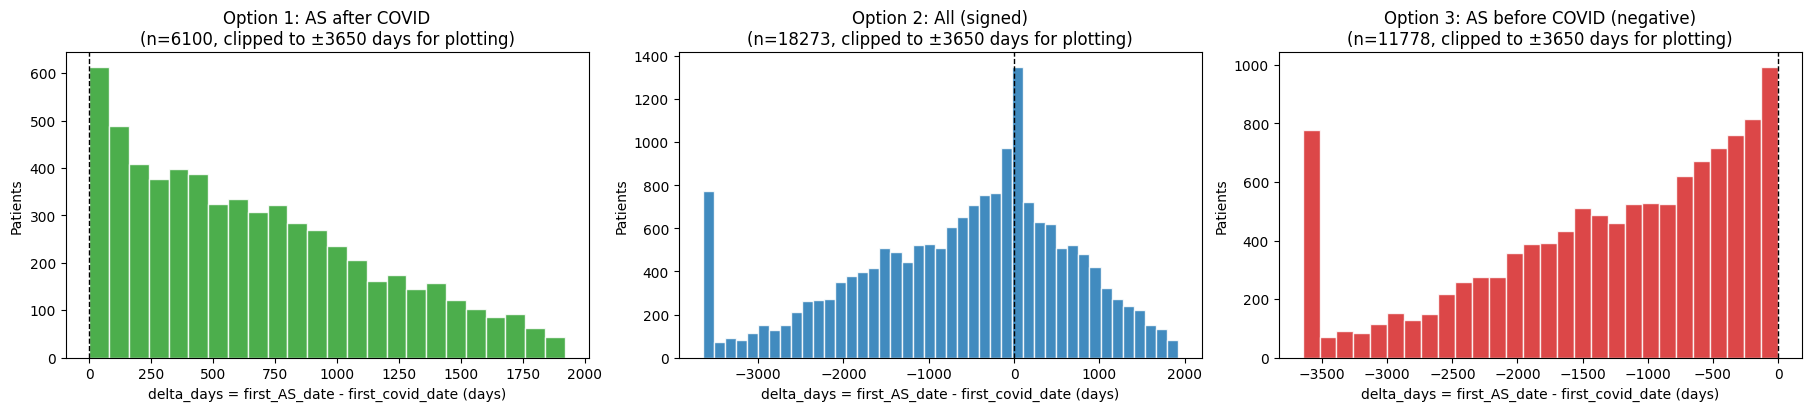

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

hist_delta(axes[0], opt1_df, "Option 1: AS after COVID", clip_days=3650, color="C2", show_zero=True)
hist_delta(axes[1], opt2_df, "Option 2: All (signed)", clip_days=3650, color="C0", show_zero=True)
hist_delta(axes[2], opt3_df, "Option 3: AS before COVID (negative)", clip_days=3650, color="C3", show_zero=True)

plt.show()

In [44]:
n_both = opt2_df.height
n_zero = int((opt2_df["delta_days"] == 0).sum())
pct_zero = n_zero / n_both * 100
n_zero, n_both, pct_zero

(395, 18273, 2.161659278717233)

In [45]:
int((opt1_df["delta_days"] == 0).sum()), int((opt3_df["delta_days"] == 0).sum())

(0, 0)

In [46]:
zeros = opt2_df.filter(pl.col("delta_days") == 0).select(
    "patient_id", "first_covid_date", "first_AS_date", "covid_year", "as_year"
)
zeros.head(20)

patient_id,first_covid_date,first_AS_date,covid_year,as_year
str,date,date,i32,i32
"""lBTC""",2020-12-08,2020-12-08,2020,2020
"""wgic""",2020-10-05,2020-10-05,2020,2020
"""cRTg""",2020-02-21,2020-02-21,2020,2020
"""lwED""",2023-02-07,2023-02-07,2023,2023
"""3QPQ""",2022-01-30,2022-01-30,2022,2022
…,…,…,…,…
"""cByK""",2020-11-12,2020-11-12,2020,2020
"""Yx1S""",2020-03-07,2020-03-07,2020,2020
"""cwlM""",2024-08-02,2024-08-02,2024,2024


In [47]:
zero_by_covid_year = (
    opt2_df
    .with_columns((pl.col("delta_days") == 0).alias("is_zero"))
    .group_by("covid_year")
    .agg(
        pl.len().alias("n"),
        pl.col("is_zero").sum().alias("n_zero"),
        (pl.col("is_zero").mean() * 100).alias("pct_zero"),
    )
    .sort("covid_year")
)
zero_by_covid_year

covid_year,n,n_zero,pct_zero
i32,u32,u32,f64
2020,6254,112,1.790854
2021,3163,71,2.244704
2022,5300,113,2.132075
2023,2097,61,2.908918
2024,1281,37,2.888368
2025,178,1,0.561798


In [48]:
zeros_flags = (
    zeros.lazy()
    .join(
        as_all_with_flags.select("patient_id", "has_AS_dx", "has_HLA_AS"),
        on="patient_id",
        how="left",
    )
    .collect()
)

zeros_flags.group_by("has_AS_dx", "has_HLA_AS").agg(pl.len().alias("n")).sort("n", descending=True)

has_AS_dx,has_HLA_AS,n
bool,bool,u32
true,false,382
false,true,7
true,true,6


In [49]:
zero_first_sources = (
    zeros
    .lazy()
    .select(
        "patient_id",
        pl.col("first_covid_date").alias("date"),
    )
    .join(
        events_with_infections.select("patient_id", "date", "covid_source"),
        on=["patient_id", "date"],
        how="left",
    )
    # If a patient has multiple COVID sources on the same first date,
    # don't double-count them as multiple rows
    .select("patient_id", "covid_source")
    .unique()
    .group_by("covid_source")
    .agg(
        pl.col("patient_id").n_unique().alias("n_patients")
    )
    .sort("n_patients", descending=True)
    .collect()
)

zero_first_sources

covid_source,n_patients
str,u32
"""strong""",307
"""lab""",92
"""weak""",71


In [50]:
# ----------------------
# Option 2 (absolute): |first_AS_date - first_covid_date|
# ----------------------

opt2_abs_df = opt2_df.with_columns(
    pl.col("delta_days").abs().alias("abs_delta_days")
)

def summarize_abs_delta_df(df: pl.DataFrame) -> pl.DataFrame:
    return df.select(
        pl.len().alias("n_patients"),
        pl.col("abs_delta_days").mean().alias("mean_abs_days"),
        pl.col("abs_delta_days").median().alias("median_abs_days"),
        pl.col("abs_delta_days").quantile(0.25).alias("p25_abs_days"),
        pl.col("abs_delta_days").quantile(0.75).alias("p75_abs_days"),
        pl.col("abs_delta_days").min().alias("min_abs_days"),
        pl.col("abs_delta_days").max().alias("max_abs_days"),
    )

opt2_abs_summary = summarize_abs_delta_df(opt2_abs_df)

opt2_abs_summary

n_patients,mean_abs_days,median_abs_days,p25_abs_days,p75_abs_days,min_abs_days,max_abs_days
u32,f64,f64,f64,f64,i64,i64
18273,1136.044875,820.0,334.0,1551.0,0,21174


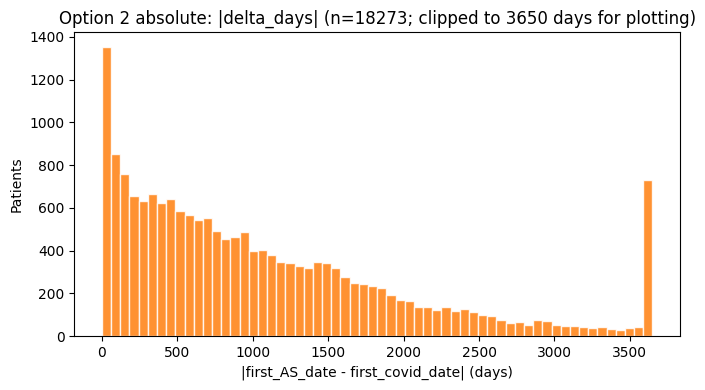

In [51]:
import numpy as np
import matplotlib.pyplot as plt

x = opt2_abs_df["abs_delta_days"].to_numpy()
x = x[np.isfinite(x)]

clip_days = 3650  # clip to ±10 years for visualization
x_plot = np.clip(x, 0, clip_days)

plt.figure(figsize=(7,4))
plt.hist(x_plot, bins=60, color="C1", alpha=0.85, edgecolor="white")
plt.title(f"Option 2 absolute: |delta_days| (n={len(x)}; clipped to {clip_days} days for plotting)")
plt.xlabel("|first_AS_date - first_covid_date| (days)")
plt.ylabel("Patients")
plt.tight_layout()
plt.show()

In [52]:
for df, label in [(opt1_df, "opt1 (after)"), (opt2_df, "opt2 (all)"), (opt3_df, "opt3 (before)")]:
    print(outlier_summary(df, label))

{'label': 'opt1 (after)', 'n': 6100, 'p1': 3.0, 'p5': 32.94999999999999, 'median': 574.5, 'p95': 1582.0500000000002, 'p99': 1820.0100000000002, 'min': 1.0, 'max': 1919.0}
{'label': 'opt2 (all)', 'n': 18273, 'p1': -5373.4, 'p5': -3289.2, 'median': -404.0, 'p95': 1234.3999999999978, 'p99': 1688.0, 'min': -21174.0, 'max': 1919.0}
{'label': 'opt3 (before)', 'n': 11778, 'p1': -5935.23, 'p5': -3886.3, 'median': -1105.0, 'p95': -77.0, 'p99': -14.0, 'min': -21174.0, 'max': -1.0}


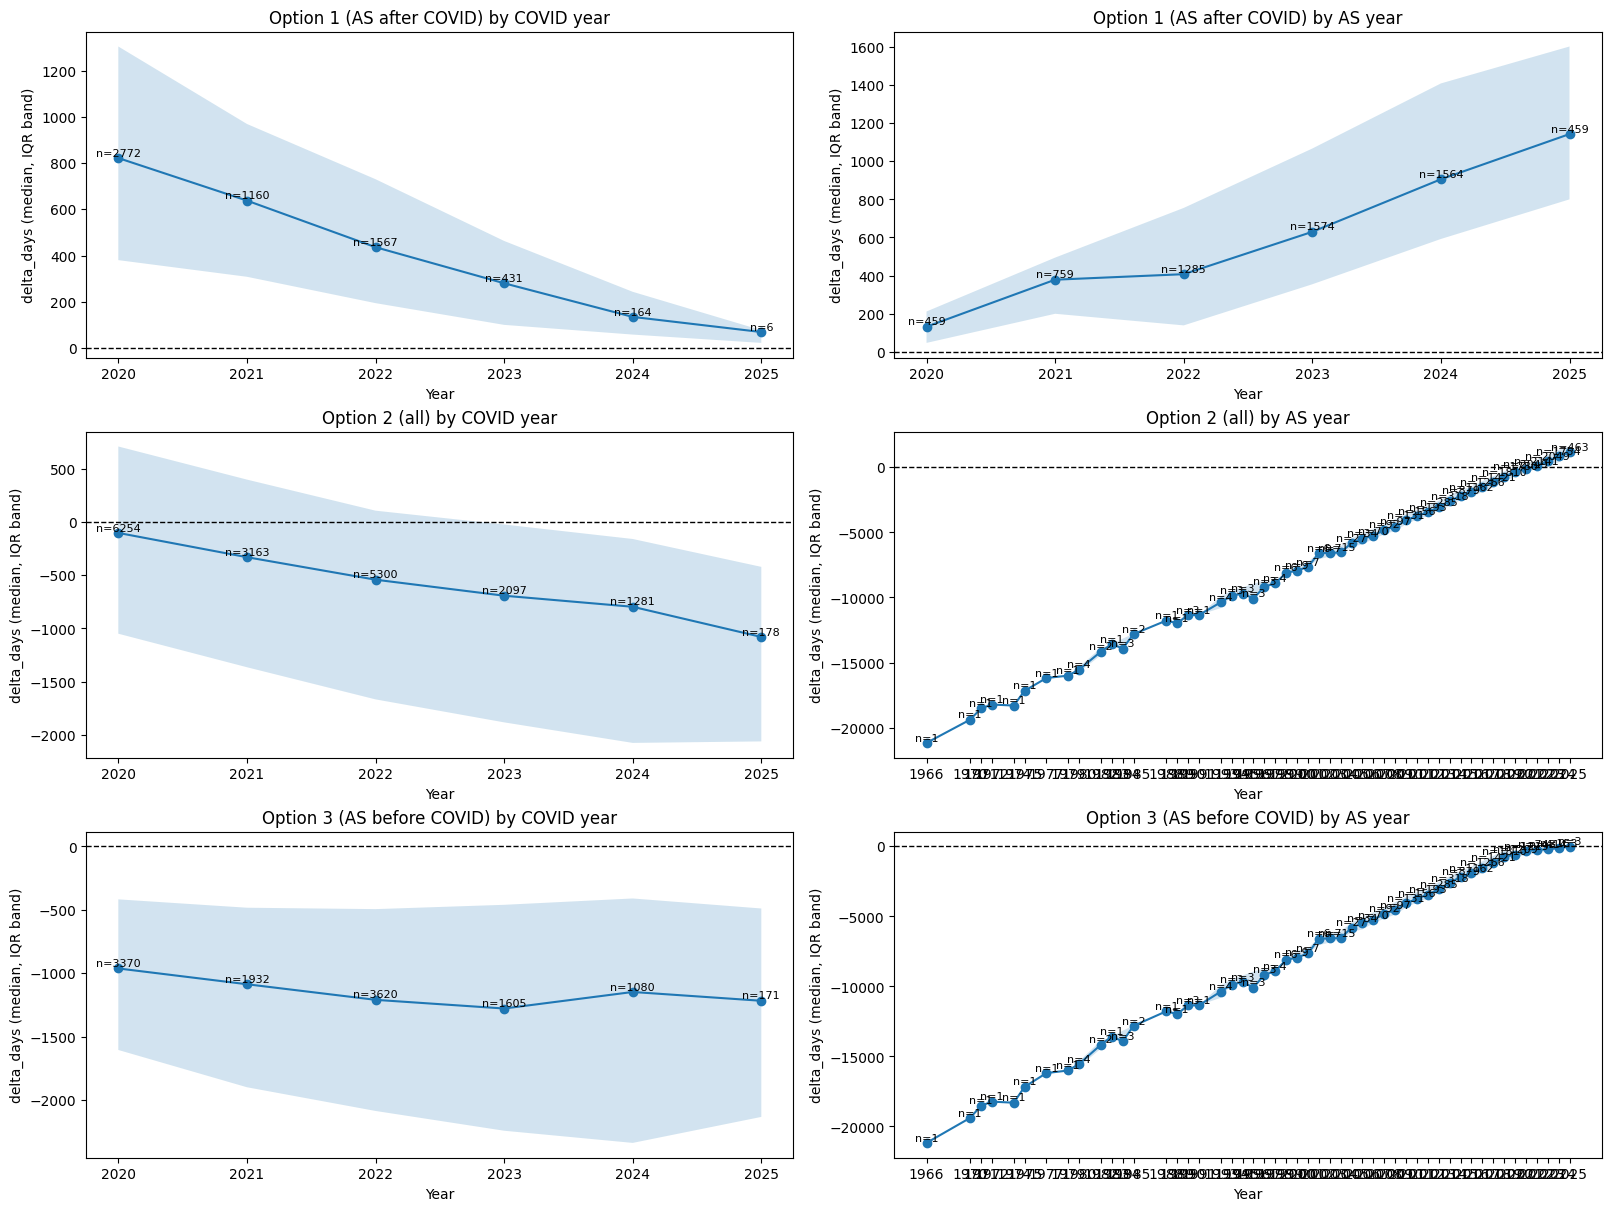

In [53]:
def year_stats(df, year_col):
    # returns pandas-like arrays via polars DataFrame
    stats = (
        df
        .filter(pl.col(year_col).is_not_null())
        .group_by(pl.col(year_col).alias("year"))
        .agg(
            pl.len().alias("n"),
            pl.col("delta_days").median().alias("median"),
            pl.col("delta_days").quantile(0.25).alias("p25"),
            pl.col("delta_days").quantile(0.75).alias("p75"),
        )
        .sort("year")
    )
    return stats

def plot_year_series(ax, stats, title):
    years = stats["year"].to_numpy()
    med = stats["median"].to_numpy()
    p25 = stats["p25"].to_numpy()
    p75 = stats["p75"].to_numpy()
    n = stats["n"].to_numpy()

    ax.plot(years, med, marker="o")
    ax.fill_between(years, p25, p75, alpha=0.2)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("delta_days (median, IQR band)")
    ax.set_xticks(years)

    # annotate n (small text)
    for x, y, nn in zip(years, med, n):
        ax.text(x, y, f"n={nn}", fontsize=8, ha="center", va="bottom")

# Build stats
opt1_covid_stats = year_stats(opt1_df, "covid_year")
opt1_as_stats    = year_stats(opt1_df, "as_year")

opt2_covid_stats = year_stats(opt2_df, "covid_year")
opt2_as_stats    = year_stats(opt2_df, "as_year")

opt3_covid_stats = year_stats(opt3_df, "covid_year")
opt3_as_stats    = year_stats(opt3_df, "as_year")

# Plot: 3 rows (options) x 2 cols (grouping)
fig, axes = plt.subplots(3, 2, figsize=(16, 12), constrained_layout=True)

plot_year_series(axes[0,0], opt1_covid_stats, "Option 1 (AS after COVID) by COVID year")
plot_year_series(axes[0,1], opt1_as_stats,    "Option 1 (AS after COVID) by AS year")

plot_year_series(axes[1,0], opt2_covid_stats, "Option 2 (all) by COVID year")
plot_year_series(axes[1,1], opt2_as_stats,    "Option 2 (all) by AS year")

plot_year_series(axes[2,0], opt3_covid_stats, "Option 3 (AS before COVID) by COVID year")
plot_year_series(axes[2,1], opt3_as_stats,    "Option 3 (AS before COVID) by AS year")

plt.show()

In [54]:
def summarize_abs_by_year_df(df: pl.DataFrame, year_col: str) -> pl.DataFrame:
    return (
        df
        .filter(pl.col(year_col).is_not_null())
        .group_by(pl.col(year_col).alias("year"))
        .agg(
            pl.len().alias("n_patients"),
            pl.col("abs_delta_days").mean().alias("mean_abs_days"),
            pl.col("abs_delta_days").median().alias("median_abs_days"),
            pl.col("abs_delta_days").quantile(0.25).alias("p25_abs_days"),
            pl.col("abs_delta_days").quantile(0.75).alias("p75_abs_days"),
        )
        .sort("year")
    )

opt2_abs_covidYear = summarize_abs_by_year_df(opt2_abs_df, "covid_year")
opt2_abs_asYear = summarize_abs_by_year_df(opt2_abs_df, "as_year")

opt2_abs_covidYear, opt2_abs_asYear

(shape: (6, 6)
 ┌──────┬────────────┬───────────────┬─────────────────┬──────────────┬──────────────┐
 │ year ┆ n_patients ┆ mean_abs_days ┆ median_abs_days ┆ p25_abs_days ┆ p75_abs_days │
 │ ---  ┆ ---        ┆ ---           ┆ ---             ┆ ---          ┆ ---          │
 │ i32  ┆ u32        ┆ f64           ┆ f64             ┆ f64          ┆ f64          │
 ╞══════╪════════════╪═══════════════╪═════════════════╪══════════════╪══════════════╡
 │ 2020 ┆ 6254       ┆ 1053.002558   ┆ 860.0           ┆ 375.0        ┆ 1449.0       │
 │ 2021 ┆ 3163       ┆ 1094.299399   ┆ 824.0           ┆ 365.0        ┆ 1414.0       │
 │ 2022 ┆ 5300       ┆ 1157.114151   ┆ 784.5           ┆ 322.0        ┆ 1667.0       │
 │ 2023 ┆ 2097       ┆ 1249.726276   ┆ 718.0           ┆ 252.0        ┆ 1883.0       │
 │ 2024 ┆ 1281       ┆ 1317.708821   ┆ 797.0           ┆ 231.0        ┆ 2076.0       │
 │ 2025 ┆ 178        ┆ 1521.544944   ┆ 1080.5          ┆ 422.0        ┆ 2062.0       │
 └──────┴────────────┴──────

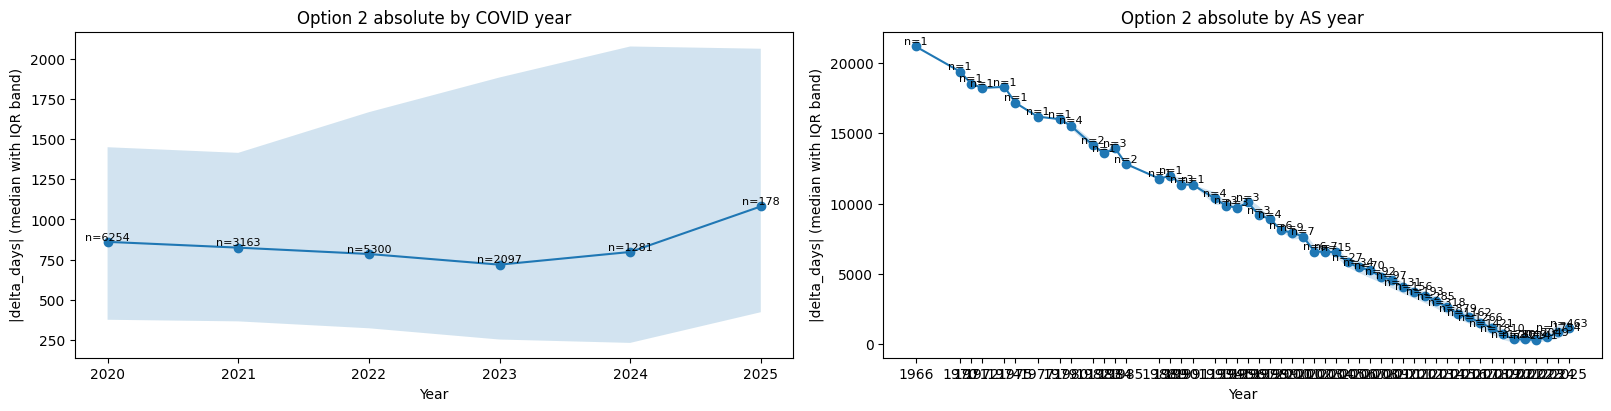

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def plot_year_abs(stats_df, title, ax):
    years = stats_df["year"].to_numpy()
    med = stats_df["median_abs_days"].to_numpy()
    p25 = stats_df["p25_abs_days"].to_numpy()
    p75 = stats_df["p75_abs_days"].to_numpy()
    n = stats_df["n_patients"].to_numpy()

    ax.plot(years, med, marker="o")
    ax.fill_between(years, p25, p75, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("|delta_days| (median with IQR band)")
    ax.set_xticks(years)

    # annotate n
    for x, y, nn in zip(years, med, n):
        ax.text(x, y, f"n={nn}", fontsize=8, ha="center", va="bottom")

fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)

plot_year_abs(opt2_abs_covidYear, "Option 2 absolute by COVID year", axes[0])
plot_year_abs(opt2_abs_asYear, "Option 2 absolute by AS year", axes[1])

plt.show()

**Unequal follow-up**

We are not giving them the same amount of time to develop AS.

Example:
COVID in 2020 → patient has ~5 years of follow-up
COVID in 2024 → patient has ~1 year of follow-up
COVID in 2025 → maybe only a few months

So naturally:
2020 cohort can have large deltas (800–1000 days)
2024 cohort physically cannot

We shoudld compare cohorts fairly. 
*We could only look at AS occurring within 1 year after COVID and during 2024-2025.*

**Furtehrmore** this is not a good comparison for AS onset. We have to compute and compare AS onset pre vs post pandemic, or COVID vs non COVID patients. To do that one should compute time window diagnosis delay of AS. 
In almost all studies calculating diagnostic delay, the onset date is defined by patient self-reporting. When a patient is finally diagnosed, the rheumatologist or researcher will ask them to look back and pinpoint when their symptoms first began.
This is plausible but hard. One easy option would be by pinpointing the first general code for lower back pain (or to be more precise, inflammatory back pain) as the start of the disease, but this is still inaccurate. Another way would be to just take patients with 

**Proposed workflow:**
For each COVID patient:

Did AS occur within 365 days?
Yes or no?
If yes, what was time-to-AS within that 365 days?

Now:
2020 patients → evaluated only in first 1 year
2024 patients → also evaluated only in first 1 year
Now the comparison is fair.




**Demographics EDA**

We will compute:
Is post-COVID AS occurring in a different demographic?
Is COVID→AS average age?
Is the male predominance shifting?
Is there selection bias?

If COVID were biologically triggering AS, you might see:

Average age at onset
Different sex distribution
Possibly compressed time to diagnosis

We need to  build a unified per‑patient AS+COVID table

In [56]:
import pandas as pd

import polars as pl
import pandas as pd

# 1) Make sure both Polars tables are materialized as DataFrames
as_all_per_patient_df = as_all_per_patient.collect()   # if not already done
infection_counts_df = infection_counts.collect()       # THIS is what was missing

# 2) Convert to pandas
as_all_per_patient_pd = as_all_per_patient_df.to_pandas()
infection_counts_pd = infection_counts_df.to_pandas()


In [57]:
panel = pd.merge(
    as_all_per_patient_pd[
        ["patient_id", "first_AS_date", "last_AS_date", "n_AS_events"]
    ],
    infection_counts_pd[
        ["patient_id", "first_infection_date", "last_infection_date", "n_infections"]
    ],
    on="patient_id",
    how="outer",   # AS-only, COVID-only, both
)

panel = panel.rename(
    columns={
        "first_infection_date": "first_covid_date",
        "last_infection_date": "last_covid_date",
    }
)

In [58]:
print(panel["patient_id"].isna().sum())

panel["has_AS"] = panel["first_AS_date"].notna()
panel["has_COVID"] = panel["first_covid_date"].notna()

print(panel[["has_AS", "has_COVID"]].value_counts())

0
has_AS  has_COVID
True    False        95973
False   True         33498
True    True         18273
Name: count, dtype: int64


In [59]:
import pandas as pd

demographics_df = pd.read_csv("/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/6830e0fee38318445f5a7020_20250527_203103261/patient.csv")
demographics_df.head()

,patient_id,sex,race,ethnicity,marital_status,year_of_birth,reason_yob_missing,month_year_death,death_date_source_id,patient_regional_location,source_id
0,5QB,M,White,Unknown,Unknown,1937.0,Present,NaN,NaN,South,EHR
1,5gB,M,Unknown,Unknown,Unknown,1982.0,Present,NaN,NaN,South,EHR
2,5wB,M,White,Not Hispanic or Latino,Single,NaN,Protected,NaN,NaN,South,EHR
3,5AC,M,White,Not Hispanic or Latino,Married,1980.0,Present,NaN,NaN,South,EHR
4,5QC,M,Unknown,Not Hispanic or Latino,Unknown,1964.0,Present,NaN,NaN,South,EHR


In [60]:
import pandas as pd
from pathlib import Path

PATIENT_PATH = Path(
    "/Users/matiaslee/LOCAL_FILES_SAFE/Dr Facelli Project 2025/AS_DS/"
    "6830e0fee38318445f5a7020_20250527_203103261/patient.csv"
)

demographics = pd.read_csv(
    PATIENT_PATH,
    usecols=[
        "patient_id",
        "sex",
        "race",
        "ethnicity",
        "year_of_birth",
        "month_year_death",
    ],
)

# `panel` is your AS+COVID per-patient table from pandas merge
panel_with_demo = panel.merge(demographics, on="patient_id", how="left")

In [61]:
panel_with_demo.head()

,patient_id,first_AS_date,last_AS_date,n_AS_events,first_covid_date,last_covid_date,n_infections,has_AS,has_COVID,sex,race,ethnicity,year_of_birth,month_year_death
0,#A0,NaT,NaT,NaN,2022-09-16,2022-09-20,1.0,False,True,F,Unknown,Unknown,2006.0,NaN
1,#A0C,2017-08-28,2017-08-28,1.0,NaT,NaT,NaN,True,False,F,White,Not Hispanic or Latino,2005.0,NaN
2,#A0D,2018-06-01,2018-06-01,1.0,NaT,NaT,NaN,True,False,M,White,Not Hispanic or Latino,2006.0,NaN
3,#A1C,2017-10-26,2018-09-05,5.0,NaT,NaT,NaN,True,False,M,White,Not Hispanic or Latino,2003.0,NaN
4,#A5,NaT,NaT,NaN,2023-02-07,2025-01-23,5.0,False,True,F,White,Not Hispanic or Latino,2006.0,NaN


In [62]:
len(panel_with_demo), panel_with_demo["patient_id"].nunique()

(147744, 147744)

In [63]:
# 0) Basic shape / duplicates
print("n_rows:", len(panel_with_demo))
print("n_unique_patient_id:", panel_with_demo["patient_id"].nunique())
print("n_duplicated_patient_id:", panel_with_demo["patient_id"].duplicated().sum())

n_rows: 147744
n_unique_patient_id: 147744
n_duplicated_patient_id: 0


In [64]:
def invalid_cat(series):
    s = series.astype("string").str.strip()
    return (
        s.isna()
        | (s == "")
        | s.isin(["Unknown", "UNK", "NaN", "NaT"])
    ).sum()

invalid_sex = invalid_cat(panel_with_demo["sex"])
invalid_race = invalid_cat(panel_with_demo["race"])
invalid_eth  = invalid_cat(panel_with_demo["ethnicity"])
invalid_yob = invalid_cat(panel_with_demo["year_of_birth"])
invalid_death = invalid_cat(panel_with_demo["month_year_death"])


print("n_invalid_sex:", invalid_sex)
print("n_invalid_race:", invalid_race)
print("n_invalid_ethnicity:", invalid_eth)
print("n_invalid_yob:", invalid_yob)
print("n_invalid_death:", invalid_death)



n_invalid_sex: 3925
n_invalid_race: 18560
n_invalid_ethnicity: 27339
n_invalid_yob: 2288
n_invalid_death: 140606


In [65]:
panel_with_demo.isna().sum()

patient_id               0
first_AS_date        33498
last_AS_date         33498
n_AS_events          33498
first_covid_date     95973
last_covid_date      95973
n_infections         95973
has_AS                   0
has_COVID                0
sex                   3925
race                     0
ethnicity                0
year_of_birth         2288
month_year_death    140606
dtype: int64

In [66]:
n_as_patients = panel_with_demo["has_AS"].sum()
n_covid_patients = panel_with_demo["has_COVID"].sum()

print("AS patients:", n_as_patients)
print("COVID patients:", n_covid_patients)

print(panel_with_demo[["has_AS", "has_COVID"]].value_counts())

AS patients: 114246
COVID patients: 51771
has_AS  has_COVID
True    False        95973
False   True         33498
True    True         18273
Name: count, dtype: int64


In [67]:
import pandas as pd


panel = panel_with_demo.copy()

panel["first_AS_date"] = pd.to_datetime(panel["first_AS_date"])
panel["first_covid_date"] = pd.to_datetime(panel["first_covid_date"])

# keep year_of_birth numeric; coerce bad values to NaN
panel["year_of_birth"] = pd.to_numeric(panel["year_of_birth"], errors="coerce")

In [68]:
# AS patients only
as_patients = panel[panel["has_AS"]].copy()

# age at first AS diagnosis
as_patients["age_at_AS"] = (
    as_patients["first_AS_date"].dt.year - as_patients["year_of_birth"]
)

# drop clearly invalid ages (optional, but sensible)
as_patients = as_patients[
    as_patients["age_at_AS"].between(0, 120)
]

**Analysis A – Pre‑ vs Post‑COVID AS (calendar split at 2020‑01‑01)**

In [69]:
import numpy as np

CUTOFF = pd.Timestamp("2020-01-01")

as_patients["pre_post_group"] = np.where(
    as_patients["first_AS_date"] < CUTOFF,
    "pre_covid_AS",
    "post_covid_AS",
)

In [70]:
age_summary_A = (
    as_patients
    .groupby("pre_post_group")["age_at_AS"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "n"})
)
print(age_summary_A)

                    n       mean        std
pre_post_group                             
post_covid_AS   56970  51.255345  17.856250
pre_covid_AS    55227  47.347421  17.547614


In [71]:
sex_dist_A = (
    as_patients
    .groupby("pre_post_group")["sex"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
print(sex_dist_A)

  pre_post_group sex        pct
0  post_covid_AS   F  52.832606
1  post_covid_AS   M  47.167394
2   pre_covid_AS   M  55.454257
3   pre_covid_AS   F  44.545743


“Pre COVID population and post COVID — what is the average age? What is the gender distribution?”

**Analysis B – COVID→AS vs AS‑only (within AS patients)**

In [72]:
covid_then_as_mask = (
    as_patients["has_COVID"]
    & (as_patients["first_covid_date"] < as_patients["first_AS_date"])
)

as_patients["covid_as_group"] = np.where(
    covid_then_as_mask,
    "COVID_then_AS",
    "AS_only",
)

In [73]:
age_summary_B = (
    as_patients
    .groupby("covid_as_group")["age_at_AS"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "n"})
)
print(age_summary_B)

                     n       mean        std
covid_as_group                              
AS_only         106224  48.983478  17.781754
COVID_then_AS     5973  55.525197  17.210749


In [74]:
sex_dist_B = (
    as_patients
    .groupby("covid_as_group")["sex"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
print(sex_dist_B)

  covid_as_group sex        pct
0        AS_only   M  52.007018
1        AS_only   F  47.992982
2  COVID_then_AS   F  62.452504
3  COVID_then_AS   M  37.547496


What is the gender and age distribution between those who had COVID, then AS and those who had only AS?

In [75]:
# assumes `as_patients` is already defined as in the earlier analysis
# (AS patients with valid age_at_AS, first_AS_date, has_COVID, first_covid_date)

# COVID → AS: had COVID before first AS
covid_then_as = as_patients[
    as_patients["has_COVID"]
    & as_patients["first_covid_date"].notna()
    & (as_patients["first_covid_date"] < as_patients["first_AS_date"])
].copy()

# AS-only: AS patients with no COVID at all
as_only = as_patients[~as_patients["has_COVID"]].copy()

python(15343) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


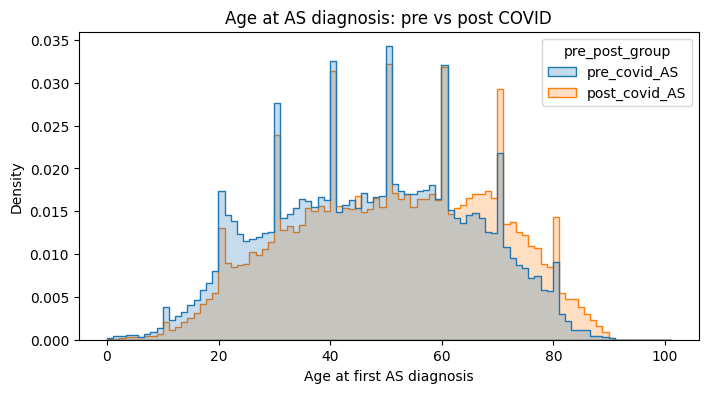

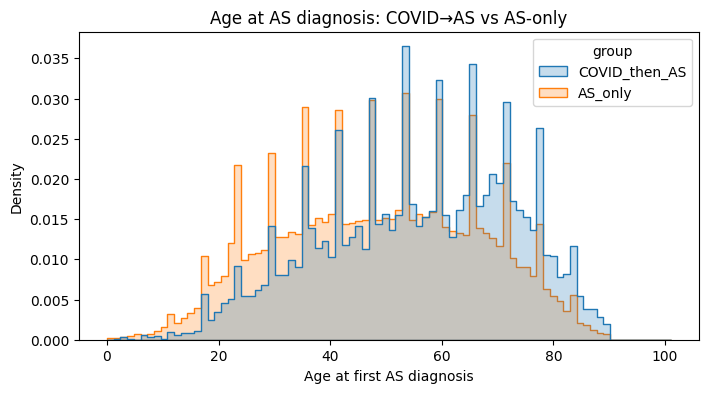

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pre vs post COVID AS
plt.figure(figsize=(8, 4))
sns.histplot(
    data=as_patients,
    x="age_at_AS",
    hue="pre_post_group",
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Age at AS diagnosis: pre vs post COVID")
plt.xlabel("Age at first AS diagnosis")
plt.show()

# COVID→AS vs AS-only (only AS patients)
cmp = pd.concat([
    covid_then_as.assign(group="COVID_then_AS"),
    as_only.assign(group="AS_only"),
])

plt.figure(figsize=(8, 4))
sns.histplot(
    data=cmp,
    x="age_at_AS",
    hue="group",
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Age at AS diagnosis: COVID→AS vs AS-only")
plt.xlabel("Age at first AS diagnosis")
plt.show()

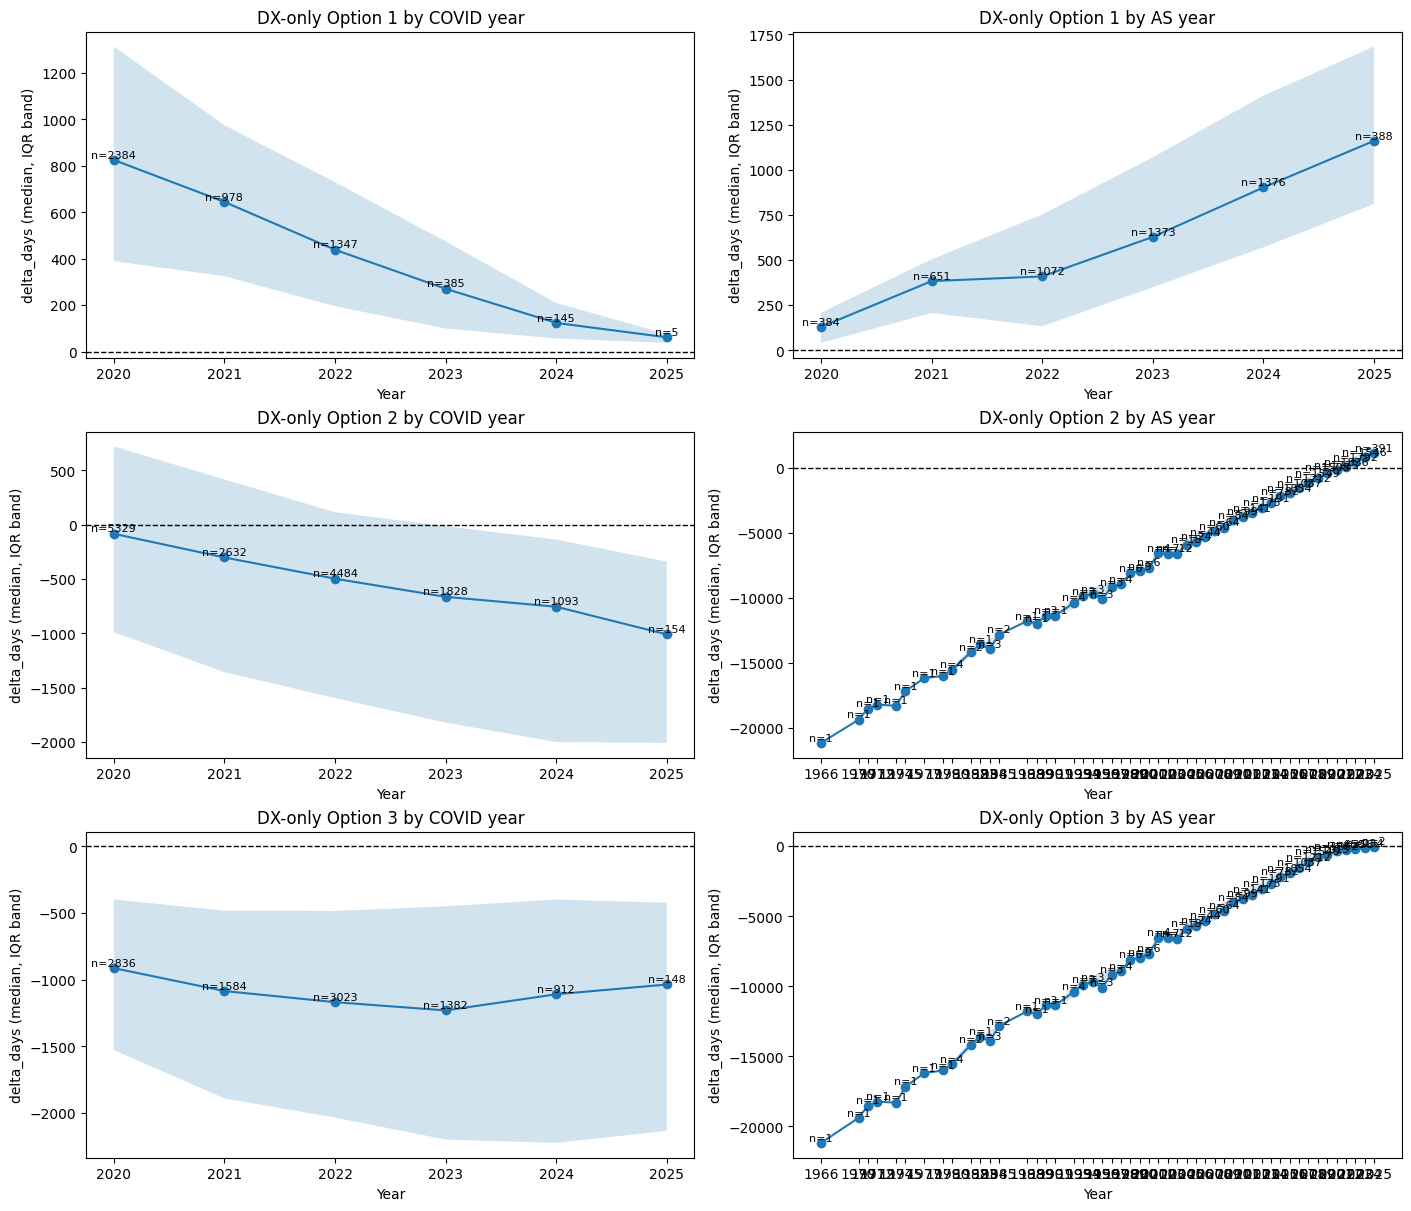

In [85]:
# ----------------------
# DX-only year-wise summaries and plots
# Uses AS diagnosis codes only (M45*), excluding HLA-positive labs
# ----------------------

# 1) Build a diagnosis-only AS-per-patient table
as_dx_per_patient = (
    as_dx_patients
    .group_by("patient_id")
    .agg(
        pl.len().alias("n_AS_dx_events"),
        pl.col("dx_date").min().alias("first_AS_date"),
        pl.col("dx_date").max().alias("last_AS_date"),
    )
)

# 2) Use the same COVID first-date table as before
covid_first = infection_counts.select(
    "patient_id",
    pl.col("first_infection_date").alias("first_covid_date"),
)

# 3) Build dx-only patient dates table
patient_dates_dx = (
    as_dx_per_patient
    .select(
        "patient_id",
        "first_AS_date",
    )
    .join(covid_first, on="patient_id", how="full")
    .with_columns(
        (
            pl.col("first_AS_date").cast(pl.Int64)
            - pl.col("first_covid_date").cast(pl.Int64)
        ).alias("delta_days"),
        pl.col("first_covid_date").dt.year().alias("covid_year"),
        pl.col("first_AS_date").dt.year().alias("as_year"),
    )
)

patient_dates_dx_df = patient_dates_dx.collect()

# 4) Keep only patients with both dates
both_dates_dx_df = patient_dates_dx_df.filter(
    pl.col("first_covid_date").is_not_null() &
    pl.col("first_AS_date").is_not_null()
)

# 5) Split into the same three timing options
opt1_dx_df = both_dates_dx_df.filter(pl.col("first_AS_date") > pl.col("first_covid_date"))
opt2_dx_df = both_dates_dx_df
opt3_dx_df = both_dates_dx_df.filter(pl.col("first_AS_date") < pl.col("first_covid_date"))

# 6) Year-wise summaries using your existing function
opt1_dx_covidYear = summarize_delta_by_year_df(opt1_dx_df, "covid_year")
opt1_dx_asYear    = summarize_delta_by_year_df(opt1_dx_df, "as_year")

opt2_dx_covidYear = summarize_delta_by_year_df(opt2_dx_df, "covid_year")
opt2_dx_asYear    = summarize_delta_by_year_df(opt2_dx_df, "as_year")

opt3_dx_covidYear = summarize_delta_by_year_df(opt3_dx_df, "covid_year")
opt3_dx_asYear    = summarize_delta_by_year_df(opt3_dx_df, "as_year")

# 7) Helper to rename columns so they match plot_year_series()
def prep_year_plot(df: pl.DataFrame) -> pl.DataFrame:
    return df.rename({
        "n_patients": "n",
        "median_days": "median",
        "p25_days": "p25",
        "p75_days": "p75",
    })

opt1_dx_covidYear_plot = prep_year_plot(opt1_dx_covidYear)
opt1_dx_asYear_plot    = prep_year_plot(opt1_dx_asYear)

opt2_dx_covidYear_plot = prep_year_plot(opt2_dx_covidYear)
opt2_dx_asYear_plot    = prep_year_plot(opt2_dx_asYear)

opt3_dx_covidYear_plot = prep_year_plot(opt3_dx_covidYear)
opt3_dx_asYear_plot    = prep_year_plot(opt3_dx_asYear)

# 8) Plot the year-wise summaries
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

plot_year_series(axes[0,0], opt1_dx_covidYear_plot, "DX-only Option 1 by COVID year")
plot_year_series(axes[0,1], opt1_dx_asYear_plot,    "DX-only Option 1 by AS year")

plot_year_series(axes[1,0], opt2_dx_covidYear_plot, "DX-only Option 2 by COVID year")
plot_year_series(axes[1,1], opt2_dx_asYear_plot,    "DX-only Option 2 by AS year")

plot_year_series(axes[2,0], opt3_dx_covidYear_plot, "DX-only Option 3 by COVID year")
plot_year_series(axes[2,1], opt3_dx_asYear_plot,    "DX-only Option 3 by AS year")

plt.show()

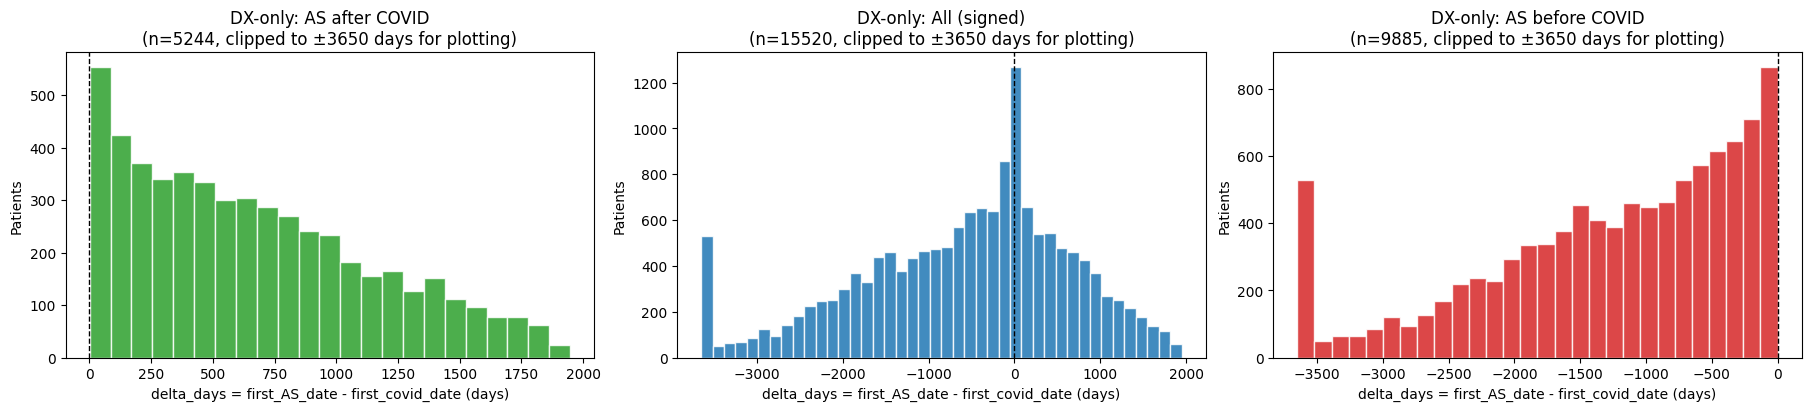

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

hist_delta(axes[0], opt1_dx_df, "DX-only: AS after COVID", clip_days=3650, color="C2", show_zero=True)
hist_delta(axes[1], opt2_dx_df, "DX-only: All (signed)", clip_days=3650, color="C0", show_zero=True)
hist_delta(axes[2], opt3_dx_df, "DX-only: AS before COVID", clip_days=3650, color="C3", show_zero=True)

plt.show()

In [ ]:
zeros = opt2_df.filter(pl.col("delta_days") == 0).select(
    "patient_id", "first_covid_date", "first_AS_date", "covid_year", "as_year"
)
zeros.head(20)